In [57]:
import numpy as np
import os
from dotenv import load_dotenv
import psycopg2
load_dotenv()

###### Connecting the postgres  #######################################
postgres_port = os.getenv("POSTGRES_PORT")
postgres_password = os.getenv("POSTGRES_PASSWORD")

try:
    conn = psycopg2.connect(
        dbname="postgres",
        user="postgres",
        password=postgres_password,
        host= "localhost",
        port = postgres_port
    )

    print("successfully connected")

except Exception as e:
    print(e)
########## ^^^ Connecting to postgres ########################################

## importing data
select_query = '''
SELECT
    home_elo_rating,
    away_elo_rating,
    home_momentum,
    away_momentum,
    "result"
        FROM apifootball_stats
			ORDER BY clean_date;
'''

cursor = conn.cursor()
cursor.execute(select_query)
data = cursor.fetchall()

xy = np.array([[(row[0]-row[1])**2, (row[2]-row[3])*(row[0]-row[1]), (row[2]-row[3])**2, row[0]-row[1], row[2]-row[3], row[4]] for row in data])
x = xy[:, :-1]
y = xy[:, -1]

successfully connected


***Visualise the data!!!***

In [58]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# Standardize features
scaler = StandardScaler()
x = scaler.fit_transform(x)

# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [100, 500, 1000],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg'],
    'class_weight': [None, 'balanced']
}

# Initialize the logistic regression model
log_reg = LogisticRegression(multi_class='multinomial')

# Initialize K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the grid search
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=kf,
    scoring='accuracy',
    verbose=1
)

# Fit the grid search to the data
grid_search.fit(x, y)

# Get the best parameters and best accuracy
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Accuracy: {best_accuracy}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'C': 0.01, 'class_weight': None, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Accuracy: 0.5119049027083142


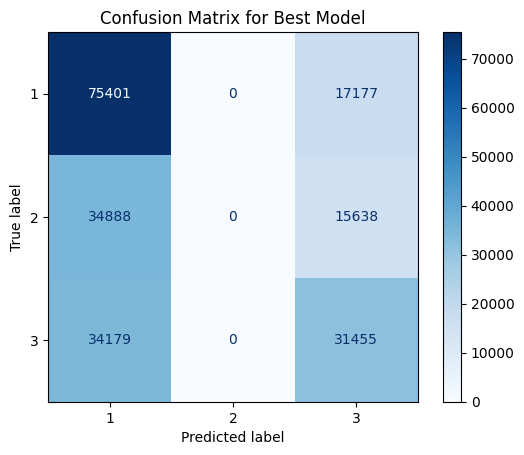

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Predict the labels for the data
y_pred = best_model.predict(x)

# Compute the confusion matrix
cm = confusion_matrix(y, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best Model')
plt.show()